In [10]:
import pandas as pd

df = pd.read_csv('Resale flat prices based on registration date from Jan-2017 onwards.csv')

df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [11]:
print("--- Dataset Info ---")
df.info()

df['price_per_sqm'] = df['resale_price'] / df['floor_area_sqm']

df.head()

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 226175 entries, 0 to 226174
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                226175 non-null  str    
 1   town                 226175 non-null  str    
 2   flat_type            226175 non-null  str    
 3   block                226175 non-null  str    
 4   street_name          226175 non-null  str    
 5   storey_range         226175 non-null  str    
 6   floor_area_sqm       226175 non-null  float64
 7   flat_model           226175 non-null  str    
 8   lease_commence_date  226175 non-null  int64  
 9   remaining_lease      226175 non-null  str    
 10  resale_price         226175 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 19.0 MB


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,price_per_sqm
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,5272.727273
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,3731.343284
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,3910.447761
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,3897.058824
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,3955.223881


C:\Users\alson\AppData\Local\Temp\ipykernel_4984\3827204606.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=town_prices.values, y=town_prices.index, palette="viridis")


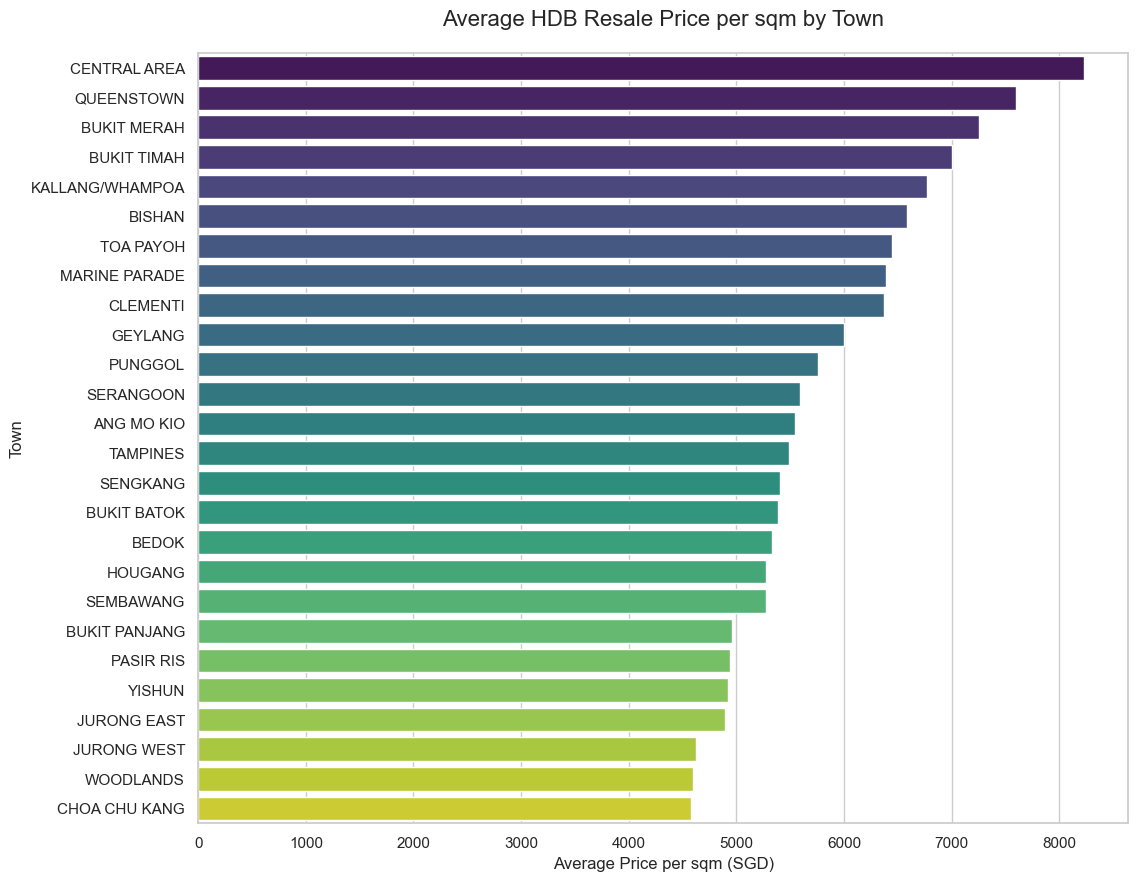

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

town_prices = df.groupby('town')['price_per_sqm'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 10))

sns.barplot(x=town_prices.values, y=town_prices.index, palette="viridis") 

plt.title('Average HDB Resale Price per sqm by Town', fontsize=16, pad=20)
plt.xlabel('Average Price per sqm (SGD)', fontsize=12)
plt.ylabel('Town', fontsize=12)

plt.show()

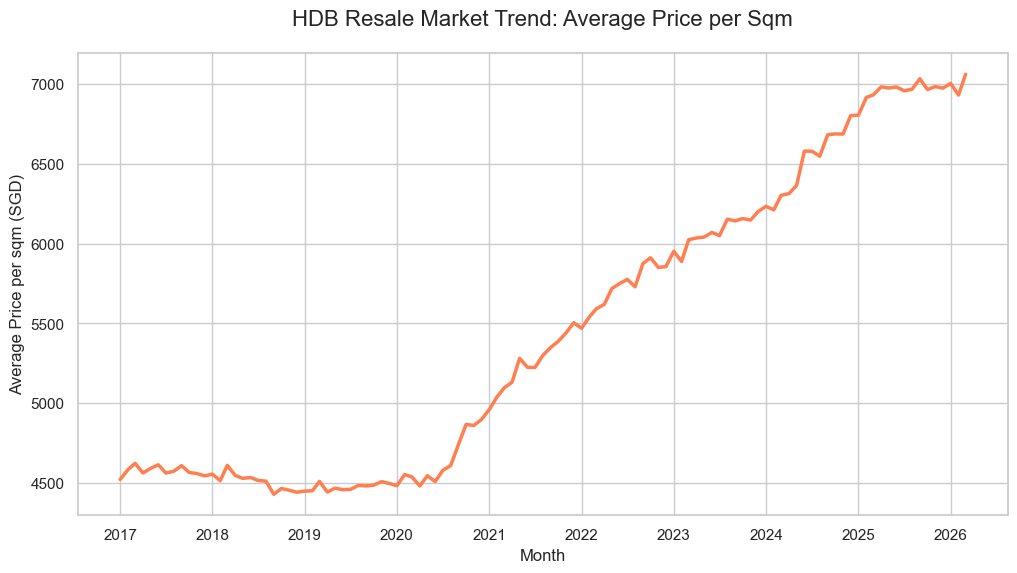

In [13]:
df.month = pd.to_datetime(df['month'])

trend_data = df.groupby('month')['price_per_sqm'].mean()

plt.figure(figsize=(12, 6))

sns.lineplot(x=trend_data.index, y=trend_data.values, color='coral', linewidth=2.5)

plt.title('HDB Resale Market Trend: Average Price per Sqm', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Price per sqm (SGD)', fontsize=12)

plt.show()

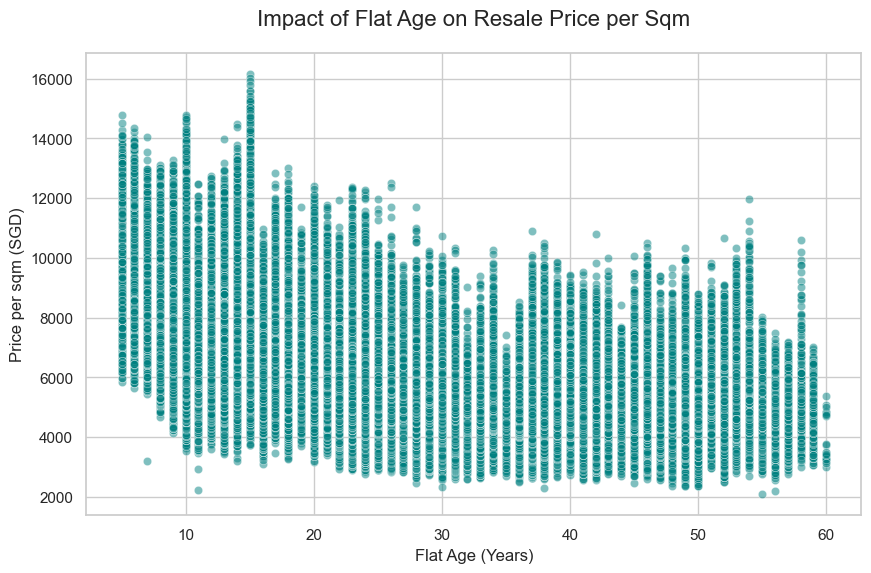

In [14]:
df['flat_age'] = 2026 - df['lease_commence_date']

plt.figure(figsize=(10,6))

sns.scatterplot(x=df['flat_age'], y=df['price_per_sqm'], alpha=0.5, color='teal')

plt.title('Impact of Flat Age on Resale Price per Sqm', fontsize=16, pad=20)
plt.xlabel('Flat Age (Years)', fontsize=12)
plt.ylabel('Price per sqm (SGD)', fontsize=12)

plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import pandas as pd

print("Preparing data for modeling...")

#Define features and target variable
#Using Area, Age and Town to predict the Price
#Use pd.get_dummies to convert the text towns into numerical columns
X = pd.get_dummies(df[['floor_area_sqm', 'flat_age', 'town']], drop_first=True)
y = df['resale_price']

#Using 20% of the data for testing and 80% for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Linear Regression model...")
model = LinearRegression()
model.fit(X_train, y_train)

#Predicting using the test set
predictions = model.predict(X_test)

#Evaluating the model using Mean Absolute Error
mae = mean_absolute_error(y_test, predictions)
print(f"On average, this model's price prediction is off by: ${mae:.2f}")

Preparing data for modeling...
Training Linear Regression model...
On average, this model's price prediction is off by: $83695.22


In [16]:
results = pd.DataFrame({
    'Actual Price': y_test.head(),
    'Predicted Price': predictions[:5]
})

results['Difference (Error)'] = results['Actual Price'] - results['Predicted Price']

print("--- Model Predictions vs Real Prices ---")
print(results.round(2))

--- Model Predictions vs Real Prices ---
        Actual Price  Predicted Price  Difference (Error)
170754      690000.0        575472.23           114527.77
172754      710000.0        663887.21            46112.79
4256        790000.0        798567.52            -8567.52
102221      428000.0        553407.19          -125407.19
58805       800000.0        874518.90           -74518.90


In [18]:
#Sorting storey range
sorted_storey = sorted(df['storey_range'].unique())

#Creating a mapping of storey range to numerical values
storey_mapping = {range_val: index + 1 for index, range_val in enumerate(sorted_storey)}

df['storey_rank'] = df['storey_range'].map(storey_mapping)

print("--- Checking Ordinal Ranking ---")
print(df[['storey_range', 'storey_rank']].head(10))

#Adding new variable to the model for higher accuracy
X_rank = pd.get_dummies(df[['floor_area_sqm', 'flat_age', 'town']], drop_first=True)
X_rank['storey_rank'] = df['storey_rank']
y = df['resale_price']

#20% for testing
X_train_rank, X_test_rank, y_train_rank, y_test_rank = train_test_split(X_rank, y, test_size=0.2, random_state=42)

model_rank = LinearRegression()
model_rank.fit(X_train_rank, y_train_rank)

predictions_rank = model_rank.predict(X_test_rank)
mae_rank = mean_absolute_error(y_test_rank, predictions_rank)

print("\n--- Final Results with Ranking ---")
print(f"Ranked Mapping MAE: ${mae_rank:.2f}")

--- Checking Ordinal Ranking ---
  storey_range  storey_rank
0     10 TO 12            4
1     01 TO 03            1
2     01 TO 03            1
3     04 TO 06            2
4     01 TO 03            1
5     01 TO 03            1
6     04 TO 06            2
7     04 TO 06            2
8     04 TO 06            2
9     01 TO 03            1

--- Final Results with Ranking ---
Ranked Mapping MAE: $81347.05


In [27]:
import pandas as pd

def predict_hdb_price(town, sqm, age, floor_rank):
    # 1. Start with the numbers the model understands directly
    input_data = {
        'floor_area_sqm': [sqm],
        'flat_age': [age],
        'storey_rank': [floor_rank]
    }
    input_df = pd.DataFrame(input_data)
    
    # 2. Format the town name exactly how the dummy columns look (e.g., 'town_BISHAN')
    town_col_name = f"town_{town.upper()}"
    
    # 3. Recreate the exact column structure the model was trained on
    for col in X_train_rank.columns:
        if col == town_col_name:
            input_df[col] = 1
        elif col not in input_df.columns:
            input_df[col] = 0
            
    # Make sure the columns are in the exact same order
    input_df = input_df[X_train_rank.columns]
    
    # 4. Ask the model to predict the price!
    predicted_price = model_rank.predict(input_df)[0]
    
    return predicted_price

# --- TEST IT OUT HERE ---
# Try changing these values to whatever you want!
my_town = 'WOODLANDS'
my_sqm = 95        # input flat size in sqm
my_age = 24         # input flat age
my_floor_rank = 4   # "01 to 03" is rank 1, "04 to 06" is rank 2, ..., "28 to 30" is rank 10

estimated_price = predict_hdb_price(town=my_town, sqm=my_sqm, age=my_age, floor_rank=my_floor_rank)

print(f"A {my_age}-year-old, {my_sqm}sqm flat in {my_town} at floor rank {my_floor_rank} is estimated at: ${estimated_price:,.2f}")

A 24-year-old, 95sqm flat in WOODLANDS at floor rank 4 is estimated at: $464,566.33
